In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.labeling import add_returns
from src.volatility import add_close_to_close_volatility

#Load data
df = pd.read_csv("../data/raw/nifty50.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

#Feature construction
df = add_returns(df)
df = add_close_to_close_volatility(df)

df = df.dropna(subset=["return", "vol_cc"]).reset_index(drop=True)

In [2]:
hmm_data = df[["return", "vol_cc"]].values #HMM inputs

## **Fit HMM Model**

In [3]:
from hmmlearn.hmm import GaussianHMM

hmm_model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm_model.fit(hmm_data)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


## **Predicting Hidden States**

In [4]:
states = hmm_model.predict(hmm_data)

df["state"] = states

In [5]:
df.head()

,Date,Open,High,Low,Close,Volume,return,vol_cc,state
0,2007-10-16,5670.649902,5708.350098,5578.450195,5668.049805,0,-0.000414,0.288382,2
1,2007-10-17,5658.899902,5658.899902,5107.299805,5559.299805,0,-0.019186,0.308638,2
2,2007-10-18,5551.100098,5736.799805,5269.649902,5351.000000,0,-0.037469,0.331769,2
3,2007-10-19,5360.350098,5390.850098,5101.750000,5215.299805,0,-0.025360,0.350485,2
4,2007-10-22,5202.750000,5247.399902,5070.899902,5184.000000,0,-0.006002,0.348319,2


## **Map States -> Regime Labels**

In [6]:
state_vol = df.groupby("state")["vol_cc"].mean().sort_values()

state_mapping = {
    state_vol.index[0]: "Low",
    state_vol.index[1]: "Medium",
    state_vol.index[2]: "High"
}

df["hmm_regime"] = df["state"].map(state_mapping)

In [7]:
#Saving again
df[["Date", "hmm_regime"]].to_csv(
    "../data/processed/hmm_regimes_refit.csv",
    index=False
)

In [8]:
df.groupby("hmm_regime").agg(
    mean_return=("return","mean"),
    mean_vol=("vol_cc","mean"),
    count=("return","size")
)

,mean_return,mean_vol,count
hmm_regime,,,
High,0.000542,0.310305,1168
Low,0.000840,0.125427,1677
Medium,-0.000145,0.125441,1672


In [9]:
hmm_model.transmat_

array([[3.41771799e-06, 9.90962054e-01, 9.03452810e-03],
       [9.95998959e-01, 1.64255242e-05, 3.98461574e-03],
       [9.42323197e-03, 1.00110196e-02, 9.80565748e-01]])

# **Regime Transition Event Analysis**

In [10]:
#Detecting transitions

df["prev_regime"] = df["hmm_regime"].shift(1)
df["transition"] = df["prev_regime"] + " -> " + df["hmm_regime"]
df.head()

,Date,Open,High,Low,Close,Volume,return,vol_cc,state,hmm_regime,prev_regime,transition
0,2007-10-16,5670.649902,5708.350098,5578.450195,5668.049805,0,-0.000414,0.288382,2,High,None,NaN
1,2007-10-17,5658.899902,5658.899902,5107.299805,5559.299805,0,-0.019186,0.308638,2,High,High,High -> High
2,2007-10-18,5551.100098,5736.799805,5269.649902,5351.000000,0,-0.037469,0.331769,2,High,High,High -> High
3,2007-10-19,5360.350098,5390.850098,5101.750000,5215.299805,0,-0.025360,0.350485,2,High,High,High -> High
4,2007-10-22,5202.750000,5247.399902,5070.899902,5184.000000,0,-0.006002,0.348319,2,High,High,High -> High


In [11]:
transitions = df[df["prev_regime"] != df["hmm_regime"]].copy()
#rows where the market changed state

In [12]:
transition_counts = transitions["transition"].value_counts()
transition_counts

transition
Medium -> Low     1667
Low -> Medium     1660
Low -> High         16
High -> Medium      12
High -> Low         10
Medium -> High       5
Name: count, dtype: int64

## **Risk stats on transition days**

In [13]:
transition_stats = transitions.groupby("transition").agg(
    mean_return=("return","mean"),
    std_return=("return","std"),
    mean_vol=("vol_cc","mean"),
    count=("return","size")
)
transition_stats

,mean_return,std_return,mean_vol,count
transition,,,,
High -> Low,0.002640,0.005252,0.180600,10
High -> Medium,-0.001168,0.005428,0.185358,12
Low -> High,-0.007919,0.032711,0.196375,16
Low -> Medium,-0.000138,0.008194,0.125008,1660
Medium -> High,-0.000487,0.038116,0.204949,5
Medium -> Low,0.000829,0.008160,0.125096,1667


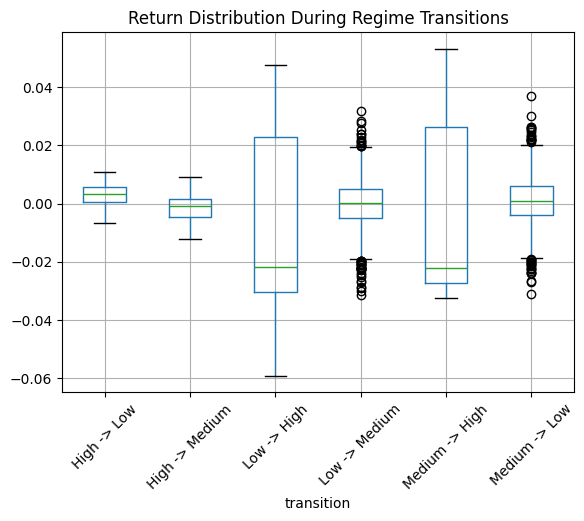

In [14]:
import matplotlib.pyplot as plt

transitions.boxplot(column="return", by="transition", rot=45)

plt.title("Return Distribution During Regime Transitions")
plt.suptitle("")
plt.show()

# **Pre Transition Volatility and Return Analysis**

In [15]:
crisis_transitions = transitions[
    transitions["transition"].isin(["Medium -> High", "Low -> High"])
].copy()
#isolating Medium -> High and Low -> High
crisis_transitions.head()

,Date,Open,High,Low,Close,Volume,return,vol_cc,state,hmm_regime,prev_regime,transition
493,2009-10-27,4970.549805,4970.549805,4829.500000,4846.700195,0,-0.024985,0.183035,2,High,Low,Low -> High
559,2010-02-03,4831.000000,4949.149902,4831.000000,4931.850098,0,0.021066,0.179756,2,High,Low,Low -> High
622,2010-05-10,5026.600098,5203.299805,5026.600098,5193.600098,0,0.034984,0.180984,2,High,Low,Low -> High
756,2010-11-16,6143.450195,6144.049805,5970.600098,5988.700195,0,-0.021710,0.186487,2,High,Low,Low -> High
810,2011-02-03,5430.450195,5532.649902,5418.000000,5526.750000,0,0.017443,0.205439,2,High,Low,Low -> High


In [16]:
lookback = 3 #defined lookback window

#pre transition behaviour extraction
pre_vol = []
pre_returns = []

for idx in crisis_transitions.index:
    if idx > lookback:
        window = df.loc[idx-lookback:idx-1]
        
        pre_vol.append(window["vol_cc"].mean())
        pre_returns.append(window["return"].mean())

pre_vol = np.array(pre_vol)
pre_returns = np.array(pre_returns)

In [17]:
#comparison with normal periods
baseline_vol = df["vol_cc"].mean()
baseline_return = df["return"].mean()

print("Baseline volatility:", baseline_vol)
print("Pre transition volatility:", pre_vol.mean())
print("\n")
print("Baseline return:", baseline_return)
print("Pre transition return:", pre_returns.mean())

Baseline volatility: 0.1732377806376293
Pre transition volatility: 0.161485855109799


Baseline return: 0.00039801534095612693
Pre transition return: -0.004232865518079169


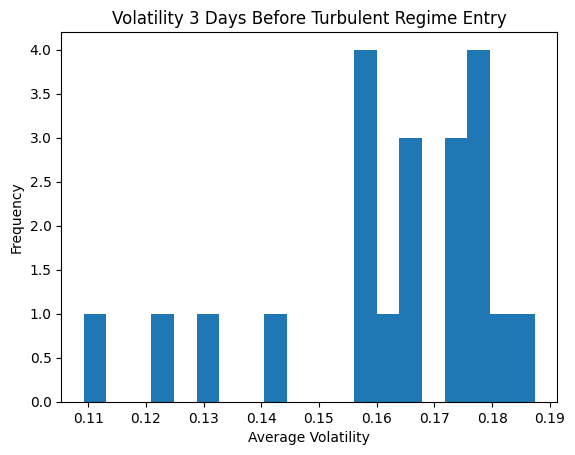

In [18]:
#visualised volatility buildup
plt.hist(pre_vol, bins=20)
plt.title("Volatility 3 Days Before Turbulent Regime Entry")
plt.xlabel("Average Volatility")
plt.ylabel("Frequency")
plt.show()

# **Regime Probability Entropy Analysis**

In [19]:
state_probs = hmm_model.predict_proba(hmm_data)
#computing state probabilities
df["P_state0"] = state_probs[:,0]
df["P_state1"] = state_probs[:,1]
df["P_state2"] = state_probs[:,2]

In [20]:
#computing entropy
def entropy(row):
    p = np.array([row["P_state0"], row["P_state1"], row["P_state2"]])
    return -np.sum(p * np.log(p + 1e-12))

df["state_entropy"] = df.apply(entropy, axis=1)

### **Comparing Entropy Before Transitions**

In [21]:
pre_entropy = []

for idx in transitions.index:
    if idx > 3:
        pre_entropy.append(df.loc[idx-3:idx-1, "state_entropy"].mean())

pre_entropy = np.array(pre_entropy)

baseline_entropy = df["state_entropy"].mean()

print("Baseline entropy:", baseline_entropy)
print("Pre transition entropy:", pre_entropy.mean())

Baseline entropy: 0.2515321507676249
Pre transition entropy: 0.32121095335183586


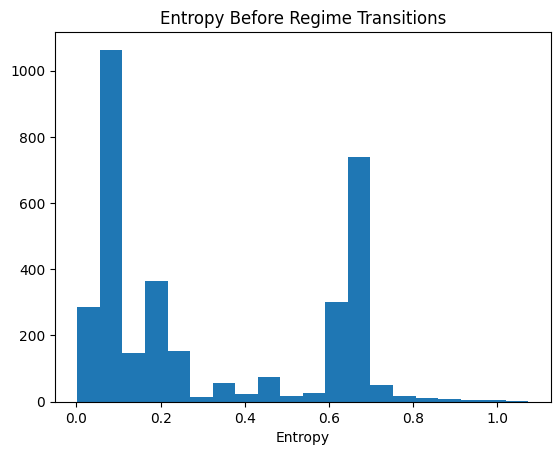

In [22]:
plt.hist(pre_entropy, bins=20)
plt.title("Entropy Before Regime Transitions")
plt.xlabel("Entropy")
plt.show()

# **Crisis Exit Analysis**

In [23]:
exit_transitions = transitions[
    transitions["transition"].isin(["High -> Medium", "High -> Low"])
].copy()

exit_transitions.head()

,Date,Open,High,Low,Close,Volume,return,vol_cc,state,hmm_regime,prev_regime,transition
467,2009-09-14,4830.350098,4832.250000,4786.250000,4808.600098,0,-0.004338,0.179770,1,Medium,High,High -> Medium
518,2009-12-02,5122.750000,5161.750000,5111.750000,5123.250000,0,0.000244,0.195895,0,Low,High,High -> Low
578,2010-03-04,5096.950195,5096.950195,5049.000000,5080.250000,0,-0.001543,0.194674,1,Medium,High,High -> Medium
654,2010-06-23,5316.149902,5333.299805,5288.149902,5323.149902,0,0.001241,0.185662,1,Medium,High,High -> Medium
778,2010-12-20,5926.850098,5985.000000,5900.250000,5947.049805,0,-0.000286,0.189100,1,Medium,High,High -> Medium


In [24]:
exit_counts = exit_transitions["transition"].value_counts()
exit_counts

transition
High -> Medium    12
High -> Low       10
Name: count, dtype: int64

In [25]:
#exit day stats
exit_stats = exit_transitions.groupby("transition").agg(
    mean_return=("return","mean"),
    std_return=("return","std"),
    mean_vol=("vol_cc","mean"),
    count=("return","size")
)
exit_stats

,mean_return,std_return,mean_vol,count
transition,,,,
High -> Low,0.002640,0.005252,0.180600,10
High -> Medium,-0.001168,0.005428,0.185358,12


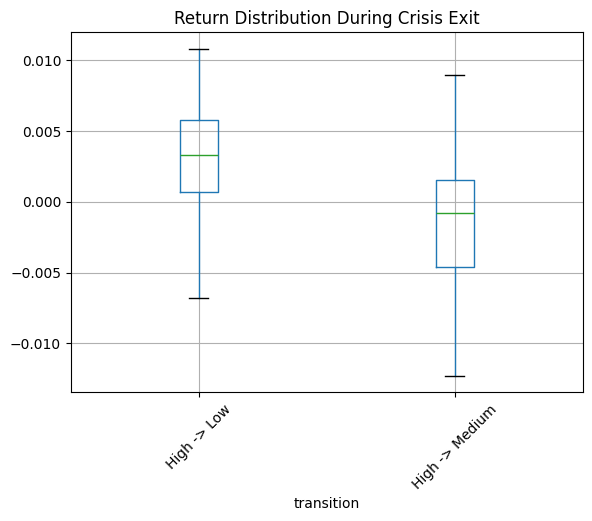

In [26]:
exit_transitions.boxplot(column="return", by="transition", rot=45)

plt.title("Return Distribution During Crisis Exit")
plt.suptitle("")
plt.show()

### **Comparing volatility before exit**

In [27]:
lookback = 3

pre_exit_vol = []

for idx in exit_transitions.index:
    if idx > lookback:
        window = df.loc[idx-lookback:idx-1]
        pre_exit_vol.append(window["vol_cc"].mean())

pre_exit_vol = np.array(pre_exit_vol)

print("Baseline volatility:", df["vol_cc"].mean())
print("Pre exit volatility:", pre_exit_vol.mean())

Baseline volatility: 0.1732377806376293
Pre exit volatility: 0.21305374148302594
